# 302b — Joint T/S probability-weighted uncertainty for depletion_q designs

This notebook evaluates **joint transmissivity-storage uncertainty** for the baseline `depletion_q` Pareto pumping designs.

It uses a 5×5 independent probability grid:

- T factors from 0.8 to 1.2
- S factors from 0.8 to 1.2
- joint probability = P(T) × P(S)

The main question is:

> When T and S are uncertain together, what is the expected streamflow uncertainty and downside risk for each pumping design?


## 1. Imports, helper reload, and user controls

Recommended workflow:

1. Run a small test with `N_TEST_MEMBERS = 10`.
2. Run the full front with `N_TEST_MEMBERS = None` and `RERUN_REEVALUATION = True`.
3. After the full cache exists, switch to `RERUN_REEVALUATION = False`.

The full 5×5 run is:

```text
296 members × 25 joint scenarios = 7,400 evaluations
```


In [11]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"
CACHE_DIR = NOTEBOOK_DIR / "cached_reevaluations"
OUTPUT_DIR = PROJECT_OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_uncertainty_depletion_q"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"

T_SIGMA_FRACTION = 0.10
S_SIGMA_FRACTION = 0.10
N_SIGMA_EACH_SIDE = 2.0
N_VALUES_EACH = 5

RERUN_REEVALUATION = False
N_TEST_MEMBERS = None

CACHE_FILE = CACHE_DIR / "302b_depletion_q_joint_T_storage_probability_reevaluation_v1.csv"
ERROR_CACHE_FILE = CACHE_DIR / "302b_depletion_q_joint_T_storage_probability_reevaluation_errors_v1.csv"

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("T_SIGMA_FRACTION:", T_SIGMA_FRACTION)
print("S_SIGMA_FRACTION:", S_SIGMA_FRACTION)
print("N_SIGMA_EACH_SIDE:", N_SIGMA_EACH_SIDE)
print("N_VALUES_EACH:", N_VALUES_EACH)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)
print("N_TEST_MEMBERS:", N_TEST_MEMBERS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-23_depletion_q_304_v2_clean_member_labels_and_reliability_plot
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/302b_depletion_q_joint_T_storage_probability_reevaluation_v1.csv
T_SIGMA_FRACTION: 0.1
S_SIGMA_FRACTION: 0.1
N_SIGMA_EACH_SIDE: 2.0
N_VALUES_EACH: 5
RERUN_REEVALUATION: False
N_TEST_MEMBERS: None


## 2. Load the depletion_q baseline context and Pareto designs

The baseline pumping designs are held fixed while T and S are perturbed together.


In [12]:
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(archive)
dv_df = up.load_decision_variable_population(context.run_dir)

if N_TEST_MEMBERS is not None:
    pareto_final = pareto_final.head(int(N_TEST_MEMBERS)).copy()

all_q_cols = up.get_q_columns(dv_df)
base_T = up.get_project_parameter_value(context.initial_dict_master, "transmissivity")
base_S = up.get_project_parameter_value(context.initial_dict_master, "storage")

print("Run directory:", context.run_dir)
print("Base T:", base_T)
print("Base S:", base_S)
print("Number of final front members selected:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of all pumping columns in dv_df:", len(all_q_cols))
print("Number of decision-variable pumping columns from PEST control file:", len(context.decvar_q_cols))

display(pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head())


Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Base T: 1700.0
Base S: 0.12
Number of final front members selected: 296
Decision-variable population shape: (8772, 327)
Number of all pumping columns in dv_df: 327
Number of decision-variable pumping columns from PEST control file: 86


,member,generation,obj_well,lpr:total_combined:bdpl
8495,152,50,17542.80,4.782580
8496,gen=36_member=6021_pso,50,7060.34,0.811083
8497,16,50,17265.50,4.489270
8498,130,50,17325.00,4.690710
8499,95,50,17459.90,4.701270


## 3. Build the joint T/S probability model

This assumes T and S are independent. That means:

```text
joint probability = T probability × S probability
```

The notebook also calculates:

```text
diffusivity factor = T factor / S factor
```

because the 301b results showed that T and S influence streamflow strongly through the hydraulic diffusivity ratio.


In [13]:
probability_table = up.make_joint_T_storage_probability_table(
    base_T=base_T,
    base_S=base_S,
    t_sigma_fraction=T_SIGMA_FRACTION,
    s_sigma_fraction=S_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    n_values_each=N_VALUES_EACH,
)

probability_path = OUTPUT_DIR / "302b_joint_T_storage_probability_grid.csv"
probability_table.to_csv(probability_path, index=False)

print("Saved probability grid:", probability_path)
print("Number of joint scenarios:", len(probability_table))
print("Sum of joint probability weights:", probability_table["joint_probability_weight"].sum())
display(probability_table)


Saved probability grid: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_grid.csv
Number of joint scenarios: 25
Sum of joint probability weights: 1.0


,scenario,T_z_score,S_z_score,T_factor,S_factor,T_value,S_value,diffusivity_factor,T_probability_weight,S_probability_weight,joint_probability_weight_raw,joint_probability_weight,scenario_label
0,Tzminus2p00_Szminus2p00,-2.0,-2.0,0.8,0.8,1360.0,0.096,1.000000,0.054489,0.054489,0.002969,0.002969,"T 0.80, S 0.80"
1,Tzminus2p00_Szminus1p00,-2.0,-1.0,0.8,0.9,1360.0,0.108,0.888889,0.054489,0.244201,0.013306,0.013306,"T 0.80, S 0.90"
2,Tzminus2p00_Szplus0p00,-2.0,0.0,0.8,1.0,1360.0,0.120,0.800000,0.054489,0.402620,0.021938,0.021938,"T 0.80, S 1.00"
3,Tzminus2p00_Szplus1p00,-2.0,1.0,0.8,1.1,1360.0,0.132,0.727273,0.054489,0.244201,0.013306,0.013306,"T 0.80, S 1.10"
4,Tzminus2p00_Szplus2p00,-2.0,2.0,0.8,1.2,1360.0,0.144,0.666667,0.054489,0.054489,0.002969,0.002969,"T 0.80, S 1.20"
5,Tzminus1p00_Szminus2p00,-1.0,-2.0,0.9,0.8,1530.0,0.096,1.125000,0.244201,0.054489,0.013306,0.013306,"T 0.90, S 0.80"
6,Tzminus1p00_Szminus1p00,-1.0,-1.0,0.9,0.9,1530.0,0.108,1.000000,0.244201,0.244201,0.059634,0.059634,"T 0.90, S 0.90"
7,Tzminus1p00_Szplus0p00,-1.0,0.0,0.9,1.0,1530.0,0.120,0.900000,0.244201,0.402620,0.098320,0.098320,"T 0.90, S 1.00"
8,Tzminus1p00_Szplus1p00,-1.0,1.0,0.9,1.1,1530.0,0.132,0.818182,0.244201,0.244201,0.059634,0.059634,"T 0.90, S 1.10"
9,Tzminus1p00_Szplus2p00,-1.0,2.0,0.9,1.2,1530.0,0.144,0.750000,0.244201,0.054489,0.013306,0.013306,"T 0.90, S 1.20"


## 4. Re-evaluate the fixed baseline designs across the joint T/S grid

This is the computationally expensive step.


In [14]:
scenarios = up.joint_probability_table_to_combined_scenarios(probability_table)
expected_rows = len(pareto_final) * len(scenarios)

print("Number of scenarios:", len(scenarios))
print("Expected rows:", expected_rows)

if RERUN_REEVALUATION or not CACHE_FILE.exists():
    results_long, error_df = up.reevaluate_depletion_q_designs_combined_T_storage(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=all_q_cols,
        context=context,
        scenarios=scenarios,
        progress_every=100,
    )
    results_long.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_CACHE_FILE)
else:
    results_long = pd.read_csv(CACHE_FILE)
    error_df = up.read_csv_if_not_empty(ERROR_CACHE_FILE)

if len(results_long) != expected_rows:
    raise ValueError(f"Cached or generated result has {len(results_long)} rows, but {expected_rows} rows were expected. Set RERUN_REEVALUATION = True to rebuild the cache for the current N_TEST_MEMBERS setting.")

print("Re-evaluation rows:", len(results_long))
print("Error rows:", len(error_df))
if not error_df.empty:
    display(error_df.head())

display(results_long.head())


Number of scenarios: 25
Expected rows: 7400
Re-evaluation rows: 7400
Error rows: 0


,member,generation,scenario,scenario_label,T_factor,S_factor,T_value,S_value,base_T_value,base_S_value,archive_pumping_objective_cfs,pumping_objective_reeval_cfs,full_model_total_pumping_cfs,archive_depletion_cfs,depletion_cfs,streamflow_cfs
0,152,50,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1360.0,0.096,1700.0,0.12,39.085358,39.085441,117.697971,4.782580,4.782582,3.817418
1,gen=36_member=6021_pso,50,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1360.0,0.096,1700.0,0.12,15.730438,15.730429,94.342958,0.811083,0.811083,7.788917
2,16,50,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1360.0,0.096,1700.0,0.12,38.467534,38.467529,117.080058,4.489270,4.489274,4.110726
3,130,50,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1360.0,0.096,1700.0,0.12,38.600100,38.600146,117.212675,4.690710,4.690711,3.909289
4,95,50,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1360.0,0.096,1700.0,0.12,38.900657,38.900681,117.513211,4.701270,4.701268,3.898732


## 5. Calculate joint probability-weighted uncertainty metrics

The main outputs are member-level and overall uncertainty metrics for joint T/S uncertainty.

The probability of streamflow shortfall uses a small tolerance (`1e-10 cfs`) so machine-precision differences around the baseline case are not counted as real shortfalls.


In [15]:
results_long = up.add_joint_probability_metadata(results_long, probability_table)

member_summary = up.summarize_joint_probability_weighted_depletion_q(results_long)
overall_summary = up.summarize_joint_probability_weighted_overall(member_summary)
grid_summary = up.summarize_joint_grid_by_scenario(results_long)

long_path = OUTPUT_DIR / "302b_joint_T_storage_probability_reevaluation_long.csv"
member_path = OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_member_summary.csv"
overall_path = OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_overall_summary.csv"
grid_summary_path = OUTPUT_DIR / "302b_joint_T_storage_grid_scenario_summary.csv"

results_long.to_csv(long_path, index=False)
member_summary.to_csv(member_path, index=False)
overall_summary.to_csv(overall_path, index=False)
grid_summary.to_csv(grid_summary_path, index=False)

print("Saved long table:", long_path)
print("Saved member summary:", member_path)
print("Saved overall summary:", overall_path)
print("Saved grid summary:", grid_summary_path)

display(member_summary.head())
display(overall_summary)
display(grid_summary.head())


Saved long table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_reevaluation_long.csv
Saved member summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_member_summary.csv
Saved overall summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_overall_summary.csv
Saved grid summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_grid_scenario_summary.csv


,member,pumping_objective_reeval_cfs,baseline_streamflow_cfs,baseline_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_absolute_depletion_error_cfs,...,best_case_T_factor,best_case_S_factor,best_case_diffusivity_factor,worst_case_T_factor,worst_case_S_factor,worst_case_diffusivity_factor,expected_diffusivity_factor,min_diffusivity_factor,max_diffusivity_factor,n_joint_scenarios
0,152,39.085441,3.817418,4.782582,3.811759,4.788241,-0.005659,0.005659,0.256745,0.256745,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
1,gen=36_member=6021_pso,15.730429,7.788917,0.811083,7.784758,0.815242,-0.004158,0.004158,0.076576,0.076576,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
2,16,38.467529,4.110726,4.489274,4.104789,4.495211,-0.005937,0.005937,0.247732,0.247732,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
3,130,38.600146,3.909289,4.690711,3.903473,4.696527,-0.005817,0.005817,0.252874,0.252874,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25
4,95,38.900681,3.898732,4.701268,3.892690,4.707310,-0.006042,0.006042,0.255962,0.255962,...,0.8,1.2,0.666667,1.2,0.8,1.5,1.009474,0.666667,1.5,25


,metric,value
0,n_members,296.000000
1,mean_expected_streamflow_bias_cfs,-0.006372
2,mean_expected_depletion_bias_cfs,0.006372
3,mean_probability_weighted_absolute_streamflow_error_cfs,0.179871
4,max_probability_weighted_absolute_streamflow_error_cfs,0.256745
5,mean_probability_weighted_absolute_depletion_error_cfs,0.179871
6,max_probability_weighted_absolute_depletion_error_cfs,0.256745
7,mean_probability_weighted_streamflow_shortfall_cfs,0.093121
8,max_probability_weighted_streamflow_shortfall_cfs,0.131202
9,mean_probability_of_streamflow_shortfall,0.356345


,scenario,scenario_label,T_factor,S_factor,diffusivity_factor,joint_probability_weight,n_members,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_depletion_change_from_baseline_cfs,mean_abs_streamflow_change_from_baseline_cfs,max_abs_streamflow_change_from_baseline_cfs
6,Tzminus2p00_Szminus2p00,"T 0.80, S 0.80",0.8,0.8,1.000000,0.002969,296,5.851079,2.748921,-6.016209e-16,5.768659e-16,1.330767e-15,5.329071e-15
5,Tzminus2p00_Szminus1p00,"T 0.80, S 0.90",0.8,0.9,0.888889,0.013306,296,6.047884,2.552116,1.968046e-01,-1.968046e-01,1.968046e-01,2.836294e-01
7,Tzminus2p00_Szplus0p00,"T 0.80, S 1.00",0.8,1.0,0.800000,0.021938,296,6.215827,2.384173,3.647473e-01,-3.647473e-01,3.647473e-01,5.295624e-01
8,Tzminus2p00_Szplus1p00,"T 0.80, S 1.10",0.8,1.1,0.727273,0.013306,296,6.361114,2.238886,5.100342e-01,-5.100342e-01,5.100342e-01,7.454990e-01
9,Tzminus2p00_Szplus2p00,"T 0.80, S 1.20",0.8,1.2,0.666667,0.002969,296,6.488262,2.111738,6.371823e-01,-6.371823e-01,6.371823e-01,9.367435e-01


## 6. Create joint T/S probability and grid-response figures

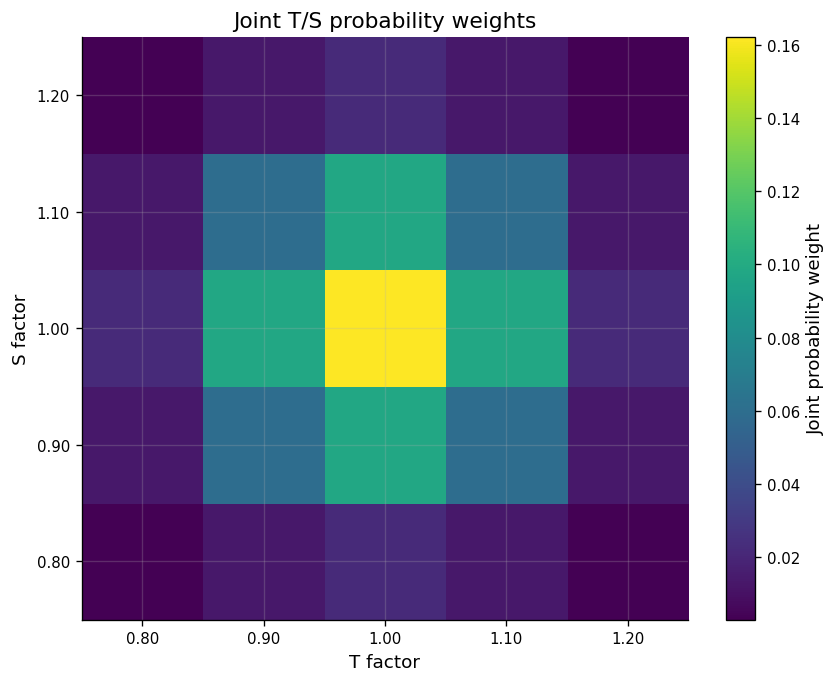

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_heatmap.png


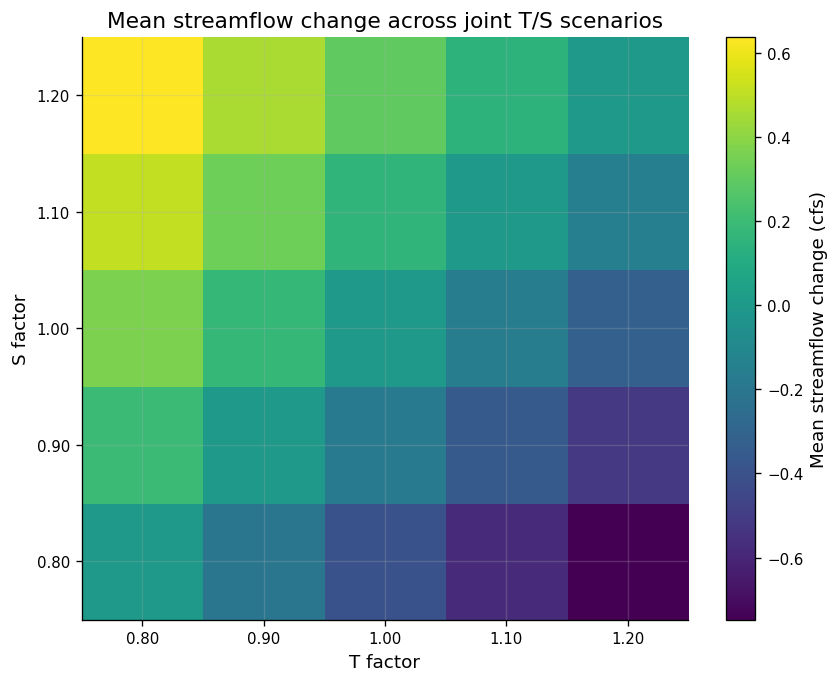

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_mean_streamflow_change_heatmap.png


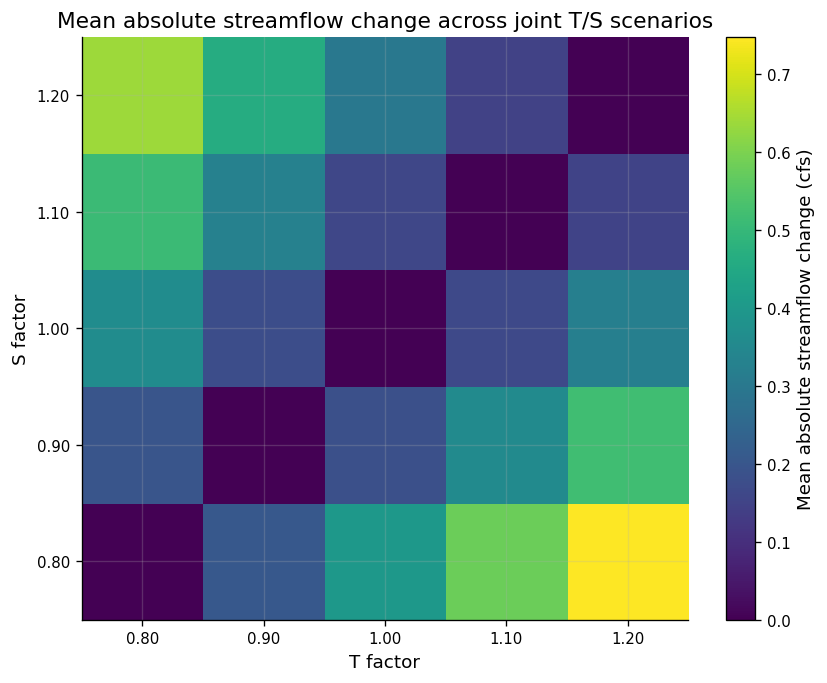

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png


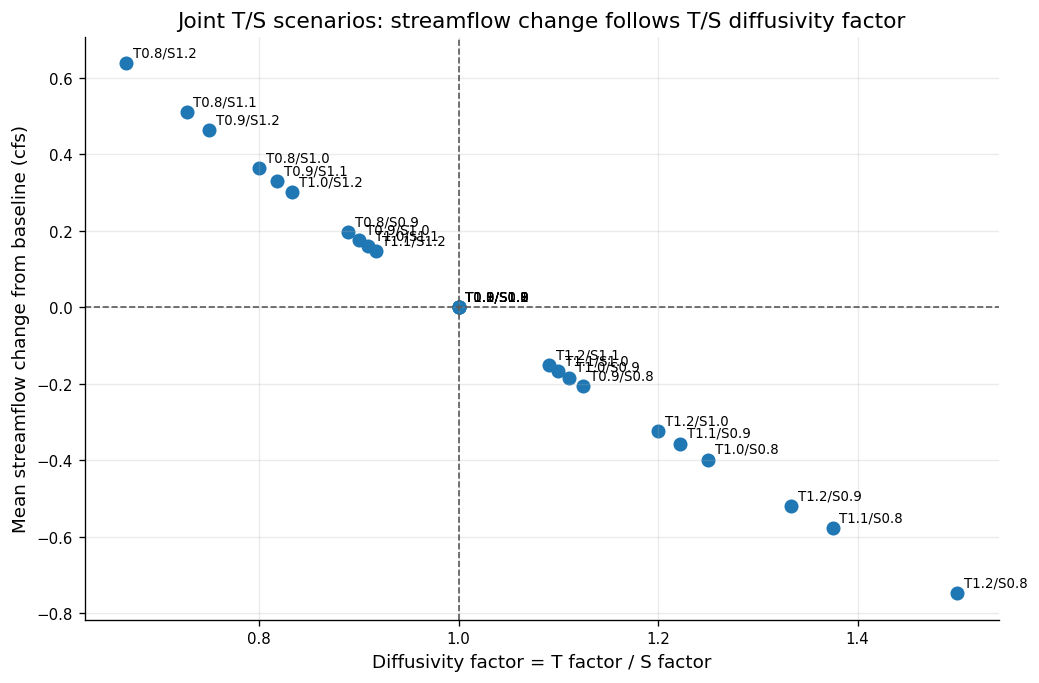

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_heatmap.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_mean_streamflow_change_heatmap.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_

In [16]:
probability_heatmap = OUTPUT_DIR / "302b_joint_T_storage_probability_heatmap.png"
mean_change_heatmap = OUTPUT_DIR / "302b_joint_T_storage_mean_streamflow_change_heatmap.png"
mean_abs_change_heatmap = OUTPUT_DIR / "302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png"
diffusivity_fig = OUTPUT_DIR / "302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png"

up.plot_joint_probability_heatmap(
    probability_table=probability_table,
    outfile=probability_heatmap,
)

up.plot_joint_grid_metric_heatmap(
    grid_summary=grid_summary,
    value_col="mean_streamflow_change_from_baseline_cfs",
    outfile=mean_change_heatmap,
    title="Mean streamflow change across joint T/S scenarios",
    cbar_label="Mean streamflow change (cfs)",
)

up.plot_joint_grid_metric_heatmap(
    grid_summary=grid_summary,
    value_col="mean_abs_streamflow_change_from_baseline_cfs",
    outfile=mean_abs_change_heatmap,
    title="Mean absolute streamflow change across joint T/S scenarios",
    cbar_label="Mean absolute streamflow change (cfs)",
)

up.plot_joint_diffusivity_vs_streamflow_change(
    grid_summary=grid_summary,
    outfile=diffusivity_fig,
)

print("Saved:", probability_heatmap)
print("Saved:", mean_change_heatmap)
print("Saved:", mean_abs_change_heatmap)
print("Saved:", diffusivity_fig)


## 7. Create joint uncertainty dashboard and metric plots

/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py:645: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


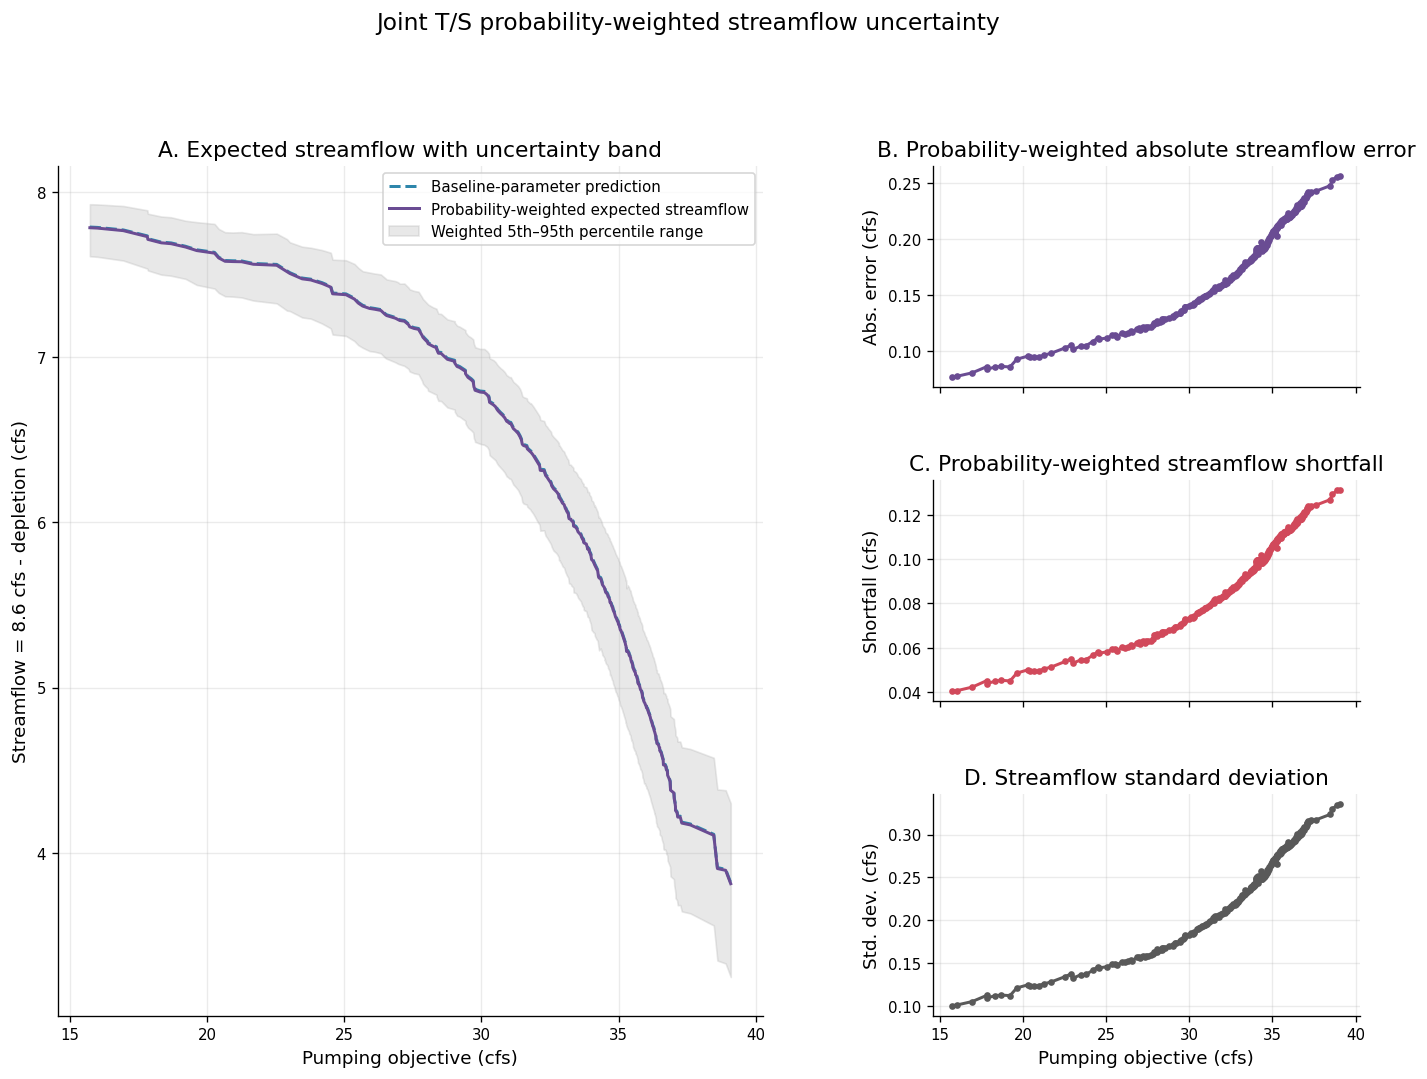

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_streamflow_uncertainty_dashboard.png


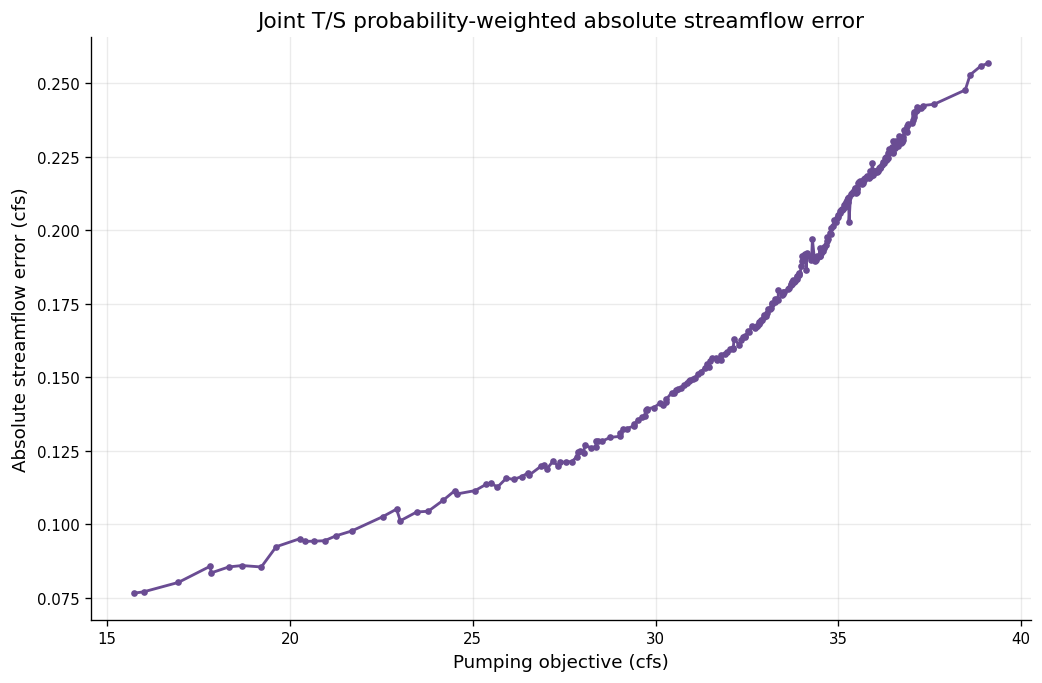

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_absolute_streamflow_error.png


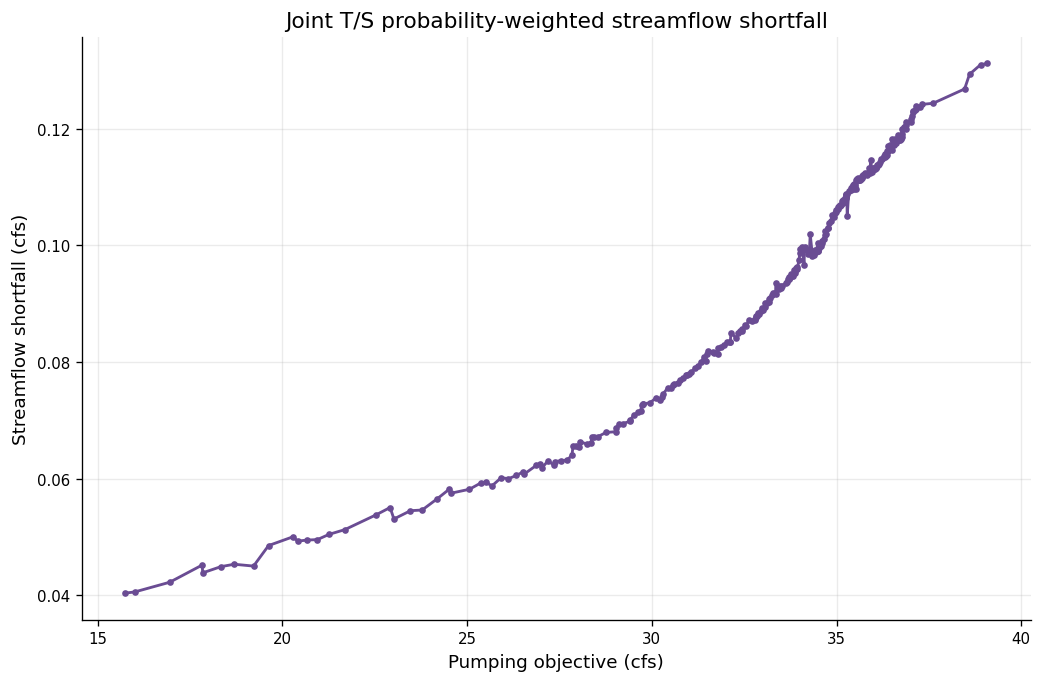

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_streamflow_shortfall.png


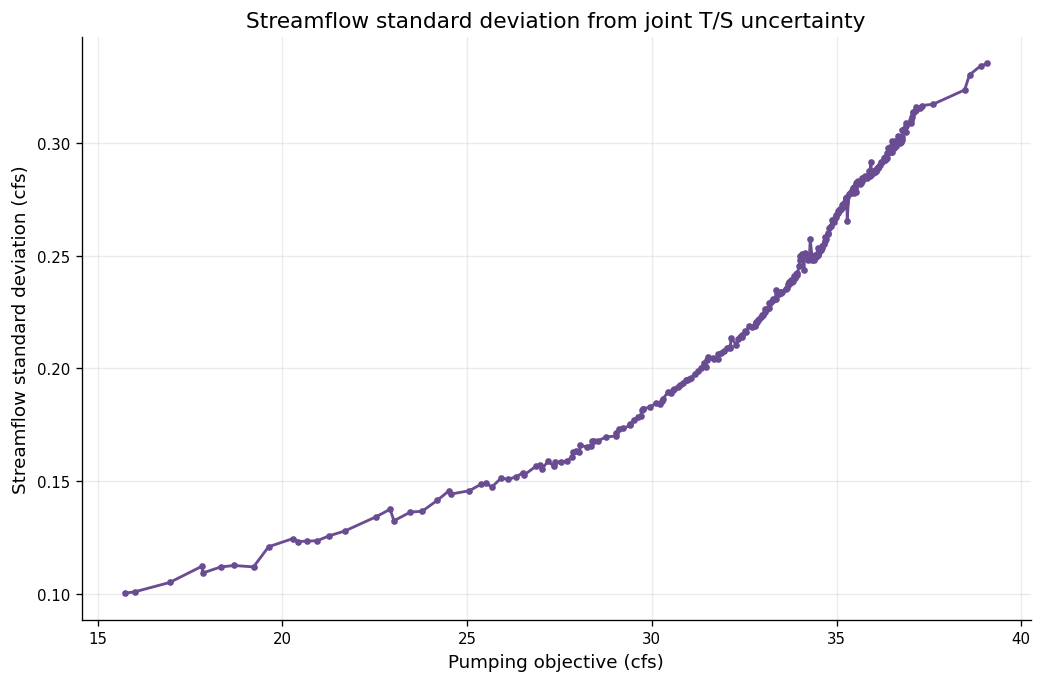

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_streamflow_standard_deviation.png


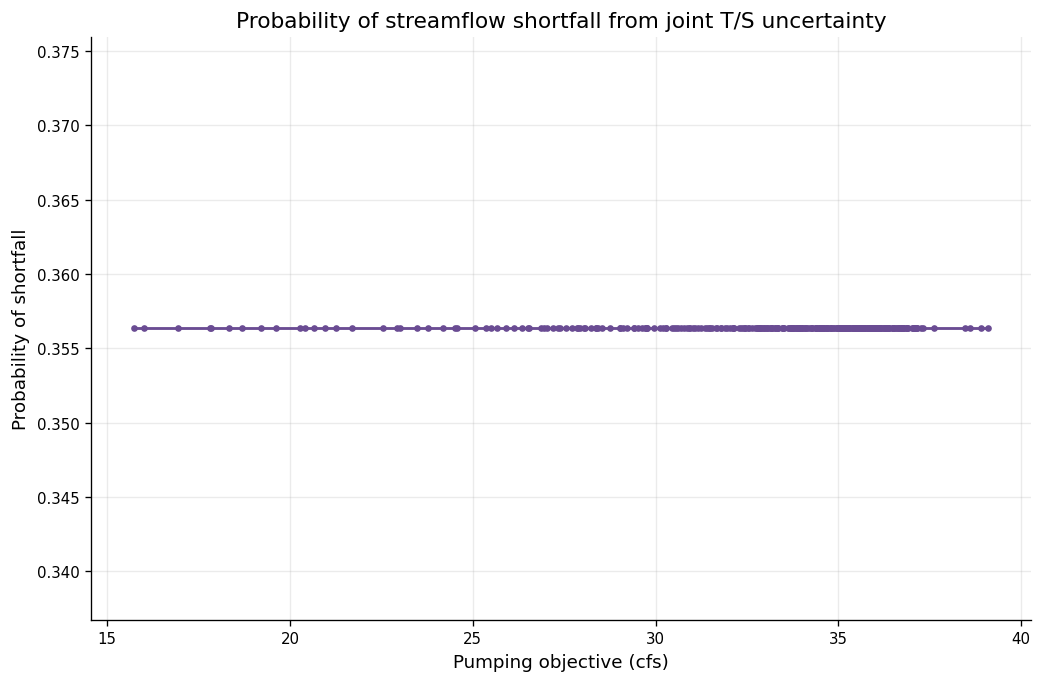

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_of_streamflow_shortfall.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_streamflow_uncertainty_dashboard.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_absolute_streamflow_error.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302b_joint_T_storage_probability_weighted_uncertainty_depletion_q/302b_joint_T_storage_probability_weighted_streamflow_shortfall.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Projec

In [17]:
dashboard_fig = OUTPUT_DIR / "302b_joint_T_storage_streamflow_uncertainty_dashboard.png"
abs_error_fig = OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_absolute_streamflow_error.png"
shortfall_fig = OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_streamflow_shortfall.png"
std_fig = OUTPUT_DIR / "302b_joint_T_storage_streamflow_standard_deviation.png"
prob_shortfall_fig = OUTPUT_DIR / "302b_joint_T_storage_probability_of_streamflow_shortfall.png"

up.plot_probability_weighted_streamflow_dashboard_depletion_q(
    member_summary=member_summary,
    outfile=dashboard_fig,
    title="Joint T/S probability-weighted streamflow uncertainty",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_absolute_streamflow_error_cfs",
    outfile=abs_error_fig,
    title="Joint T/S probability-weighted absolute streamflow error",
    ylabel="Absolute streamflow error (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_streamflow_shortfall_cfs",
    outfile=shortfall_fig,
    title="Joint T/S probability-weighted streamflow shortfall",
    ylabel="Streamflow shortfall (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="streamflow_std_cfs",
    outfile=std_fig,
    title="Streamflow standard deviation from joint T/S uncertainty",
    ylabel="Streamflow standard deviation (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_of_streamflow_shortfall",
    outfile=prob_shortfall_fig,
    title="Probability of streamflow shortfall from joint T/S uncertainty",
    ylabel="Probability of shortfall",
)

print("Saved:", dashboard_fig)
print("Saved:", abs_error_fig)
print("Saved:", shortfall_fig)
print("Saved:", std_fig)
print("Saved:", prob_shortfall_fig)


## 8. Interpret the joint probability-weighted result

This cell prints the headline metrics and identifies the highest-risk grid scenarios.


In [18]:
def scalar(metric_name):
    row = overall_summary.loc[overall_summary["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])

print("Mean probability-weighted absolute streamflow error (cfs):", scalar("mean_probability_weighted_absolute_streamflow_error_cfs"))
print("Max probability-weighted absolute streamflow error (cfs):", scalar("max_probability_weighted_absolute_streamflow_error_cfs"))
print("Mean probability-weighted streamflow shortfall (cfs):", scalar("mean_probability_weighted_streamflow_shortfall_cfs"))
print("Max probability-weighted streamflow shortfall (cfs):", scalar("max_probability_weighted_streamflow_shortfall_cfs"))
print("Mean probability of streamflow shortfall:", scalar("mean_probability_of_streamflow_shortfall"))
print("Mean streamflow standard deviation (cfs):", scalar("mean_streamflow_std_cfs"))
print("Max streamflow standard deviation (cfs):", scalar("max_streamflow_std_cfs"))

risk_grid = grid_summary.sort_values("mean_streamflow_change_from_baseline_cfs").head(5)
protective_grid = grid_summary.sort_values("mean_streamflow_change_from_baseline_cfs", ascending=False).head(5)

print("Highest-risk joint scenarios by mean streamflow change:")
display(risk_grid[["scenario_label", "T_factor", "S_factor", "diffusivity_factor", "mean_streamflow_change_from_baseline_cfs"]])

print("Most protective joint scenarios by mean streamflow change:")
display(protective_grid[["scenario_label", "T_factor", "S_factor", "diffusivity_factor", "mean_streamflow_change_from_baseline_cfs"]])


Mean probability-weighted absolute streamflow error (cfs): 0.17987079068549994
Max probability-weighted absolute streamflow error (cfs): 0.25674475840178823
Mean probability-weighted streamflow shortfall (cfs): 0.09312149720395893
Max probability-weighted streamflow shortfall (cfs): 0.131201909732794
Mean probability of streamflow shortfall: 0.3563452770013061
Mean streamflow standard deviation (cfs): 0.2350146142552865
Max streamflow standard deviation (cfs): 0.33521436406089705
Highest-risk joint scenarios by mean streamflow change:


,scenario_label,T_factor,S_factor,diffusivity_factor,mean_streamflow_change_from_baseline_cfs
21,"T 1.20, S 0.80",1.2,0.8,1.500000,-0.747752
16,"T 1.10, S 0.80",1.1,0.8,1.375000,-0.578401
20,"T 1.20, S 0.90",1.2,0.9,1.333333,-0.519646
11,"T 1.00, S 0.80",1.0,0.8,1.250000,-0.398388
15,"T 1.10, S 0.90",1.1,0.9,1.222222,-0.356789


Most protective joint scenarios by mean streamflow change:


,scenario_label,T_factor,S_factor,diffusivity_factor,mean_streamflow_change_from_baseline_cfs
9,"T 0.80, S 1.20",0.8,1.2,0.666667,0.637182
8,"T 0.80, S 1.10",0.8,1.1,0.727273,0.510034
4,"T 0.90, S 1.20",0.9,1.2,0.750000,0.463816
7,"T 0.80, S 1.00",0.8,1.0,0.800000,0.364747
3,"T 0.90, S 1.10",0.9,1.1,0.818182,0.329571


## 9. Write a short Markdown results summary

In [19]:
def fmt(value, ndigits=6):
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{ndigits}f}"

risk_row = grid_summary.sort_values("mean_streamflow_change_from_baseline_cfs").iloc[0]
protective_row = grid_summary.sort_values("mean_streamflow_change_from_baseline_cfs", ascending=False).iloc[0]

summary_text = f"""# 302b Joint T/S Probability-Weighted Uncertainty Summary

## Purpose

This notebook evaluates joint transmissivity-storage uncertainty for the baseline depletion-q Pareto pumping designs.

The joint probability model assumes T and S are independent:

joint probability = P(T) x P(S)

The 5x5 grid uses T and S factors from {probability_table["T_factor"].min():.2f} to {probability_table["T_factor"].max():.2f}.

## Headline results

| Metric | Value |
|---|---:|
| Mean probability-weighted absolute streamflow error (cfs) | {fmt(scalar("mean_probability_weighted_absolute_streamflow_error_cfs"))} |
| Max probability-weighted absolute streamflow error (cfs) | {fmt(scalar("max_probability_weighted_absolute_streamflow_error_cfs"))} |
| Mean probability-weighted streamflow shortfall (cfs) | {fmt(scalar("mean_probability_weighted_streamflow_shortfall_cfs"))} |
| Max probability-weighted streamflow shortfall (cfs) | {fmt(scalar("max_probability_weighted_streamflow_shortfall_cfs"))} |
| Mean probability of streamflow shortfall | {fmt(scalar("mean_probability_of_streamflow_shortfall"))} |
| Mean streamflow standard deviation (cfs) | {fmt(scalar("mean_streamflow_std_cfs"))} |
| Max streamflow standard deviation (cfs) | {fmt(scalar("max_streamflow_std_cfs"))} |

## Highest-risk joint scenario

The highest-risk grid scenario by mean streamflow change was:

- T factor: {risk_row["T_factor"]:.2f}
- S factor: {risk_row["S_factor"]:.2f}
- Diffusivity factor T/S: {risk_row["diffusivity_factor"]:.3f}
- Mean streamflow change from baseline: {risk_row["mean_streamflow_change_from_baseline_cfs"]:.6f} cfs

## Most protective joint scenario

The most protective grid scenario by mean streamflow change was:

- T factor: {protective_row["T_factor"]:.2f}
- S factor: {protective_row["S_factor"]:.2f}
- Diffusivity factor T/S: {protective_row["diffusivity_factor"]:.3f}
- Mean streamflow change from baseline: {protective_row["mean_streamflow_change_from_baseline_cfs"]:.6f} cfs

## Interpretation guide

The joint T/S result should be interpreted through the hydraulic diffusivity ratio:

diffusivity factor = T factor / S factor

Higher T and lower S increase diffusivity and are expected to produce greater depletion and lower streamflow. Lower T and higher S decrease diffusivity and are expected to produce less depletion and higher streamflow.
"""

summary_path = OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_results_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("Saved:", summary_path)


# 302b Joint T/S Probability-Weighted Uncertainty Summary

## Purpose

This notebook evaluates joint transmissivity-storage uncertainty for the baseline depletion-q Pareto pumping designs.

The joint probability model assumes T and S are independent:

joint probability = P(T) x P(S)

The 5x5 grid uses T and S factors from 0.80 to 1.20.

## Headline results

| Metric | Value |
|---|---:|
| Mean probability-weighted absolute streamflow error (cfs) | 0.179871 |
| Max probability-weighted absolute streamflow error (cfs) | 0.256745 |
| Mean probability-weighted streamflow shortfall (cfs) | 0.093121 |
| Max probability-weighted streamflow shortfall (cfs) | 0.131202 |
| Mean probability of streamflow shortfall | 0.356345 |
| Mean streamflow standard deviation (cfs) | 0.235015 |
| Max streamflow standard deviation (cfs) | 0.335214 |

## Highest-risk joint scenario

The highest-risk grid scenario by mean streamflow change was:

- T factor: 1.20
- S factor: 0.80
- Diffusivity factor T/S: 1.500
-

## 10. List final outputs

In [20]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png
302b_joint_T_storage_grid_scenario_summary.csv
302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png
302b_joint_T_storage_mean_streamflow_change_heatmap.png
302b_joint_T_storage_probability_grid.csv
302b_joint_T_storage_probability_heatmap.png
302b_joint_T_storage_probability_of_streamflow_shortfall.png
302b_joint_T_storage_probability_reevaluation_long.csv
302b_joint_T_storage_probability_weighted_absolute_streamflow_error.png
302b_joint_T_storage_probability_weighted_member_summary.csv
302b_joint_T_storage_probability_weighted_overall_summary.csv
302b_joint_T_storage_probability_weighted_results_summary.md
302b_joint_T_storage_probability_weighted_streamflow_shortfall.png
302b_joint_T_storage_streamflow_standard_deviation.png
302b_joint_T_storage_streamflow_uncertainty_dashboard.png
